<a href="https://colab.research.google.com/github/Pentaphone/nn_tests/blob/main/nn_test2/nn_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup

In [11]:
# INSTALLS, IMPORTS
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

!pip install torch_geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

!pip install kagglehub
import kagglehub

!pip install rdkit
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
from rdkit.Chem import rdForceFieldHelpers
from rdkit.Chem import AllChem

!pip install py3Dmol
import py3Dmol


# DOWNLOAD DATA
data_path = kagglehub.dataset_download("markinsuff/lipophilicity") + "/Lipophilicity.csv"
print("Path to dataset:", data_path)


# CONFIG
LOAD_WEIGHTS = False
TRAIN_MODEL = True
weights_path = "/content/model_weights.pth" # for loading and saving

batch_size = 32
learning_rate = 1e-4
weight_decay = 1e-3
patience = 7
limit = 100

Using Colab cache for faster access to the 'lipophilicity' dataset.
Path to dataset: /kaggle/input/lipophilicity/Lipophilicity.csv


### Utility Functions

In [12]:
def graph_from_mol(mol):
  node_features = []
  edge_indices = []

  for atom in mol.GetAtoms():
    features = [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetTotalNumHs(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
    ]
    node_features.append(features)

  node_features = torch.tensor(node_features, dtype=torch.float)

  for bond in mol.GetBonds():
    start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
    edge_indices.append([start, end])
    edge_indices.append([end, start])

  edge_indices = torch.tensor(edge_indices, dtype=torch.long)
  # transpose for torch_geometric
  edge_indices = edge_indices.t().contiguous()

  return Data(x=node_features, edge_index=edge_indices)


def mol_3d_from_mol(mol):
  mol = Chem.AddHs(mol)
  AllChem.EmbedMolecule(mol)
  # Optimize with Merck molecular force field (MMFF)
  AllChem.MMFFOptimizeMolecule(mol)

  mol_3d = Chem.MolToMolBlock(mol)
  return mol_3d

### Data

In [13]:
# data
class MoleculeDataset(Dataset):
  def __init__(self, csv_file):
    self.data = pd.read_csv(csv_file)
    self.normalize = False
    self.mean, self.std = self.data["exp"].mean(), self.data["exp"].std()

  def __len__(self):
    return len(self.data)

  def normalize_target(self, value: bool):
    self.normalize = value

  def __getitem__(self, i):
    smiles = self.data.loc[i, "RDKIT_SMILES"]
    mol = Chem.MolFromSmiles(smiles)
    graph = graph_from_mol(mol)

    exp = self.data.loc[i, "exp"]
    if self.normalize:
      exp = (exp - self.mean) / self.std

    return graph, exp


dataset = MoleculeDataset(data_path)
dataset.normalize_target(True)

train_data, test_data = torch.utils.data.random_split(dataset, [0.85, 0.15])

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


### Model

In [14]:
# MODEL
class GraphNeuralNetwork(nn.Module):
  def __init__(self):
    super(GraphNeuralNetwork, self).__init__()

    self.conv1 = GCNConv(5, 64)
    self.bn1 = nn.BatchNorm1d(64)
    self.conv2 = GCNConv(64, 128)
    self.bn2 = nn.BatchNorm1d(128)
    self.conv3 = GCNConv(128, 128)
    self.bn3 = nn.BatchNorm1d(128)

    self.pool = global_mean_pool

    self.linear = nn.Sequential(
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 1),
    )

  def forward(self, x, edge_index, batch):
    x = self.conv1(x, edge_index)
    x = self.bn1(x)
    x = torch.relu(x)
    x = self.conv2(x, edge_index)
    x = self.bn2(x)
    x = torch.relu(x)
    x = self.conv3(x, edge_index)
    x = self.bn3(x)
    x = torch.relu(x)
    x = self.pool(x, batch)
    x = self.linear(x)
    return x

  def predict(self, mol):
    with torch.no_grad():
      graph = graph_from_mol(mol)
      output = self(graph.x, graph.edge_index, graph.batch)
      logd = output.item() * dataset.std + dataset.mean
      return logd


model = GraphNeuralNetwork()

if LOAD_WEIGHTS:
  model.load_state_dict(torch.load(weights_path))

### Training and Testing

Initial model performane
Average loss (train data): 0.993226
Predicted LogD RMSE (train data): 1.198922

Average loss (test data): 1.071534
Predicted LogD RMSE (test data): 1.245288

Epoch 1/100
loss: 0.875003  [   32/ 3570]
loss: 0.936434  [  352/ 3570]
loss: 0.827024  [  672/ 3570]
loss: 0.700512  [  992/ 3570]
loss: 0.541371  [ 1312/ 3570]
loss: 0.776798  [ 1632/ 3570]
loss: 1.172181  [ 1952/ 3570]
loss: 1.014204  [ 2272/ 3570]
loss: 0.781227  [ 2592/ 3570]
loss: 0.750491  [ 2912/ 3570]
loss: 0.931191  [ 3232/ 3570]
loss: 0.853209  [ 3552/ 3570]

Evaluating
Average loss (train data): 0.920786
Predicted LogD RMSE (train data): 1.154373

Average loss (test data): 0.991589
Predicted LogD RMSE (test data): 1.197934

Epoch 2/100
loss: 0.729898  [   32/ 3570]
loss: 1.003364  [  352/ 3570]
loss: 0.820477  [  672/ 3570]
loss: 0.944048  [  992/ 3570]
loss: 1.067163  [ 1312/ 3570]
loss: 0.776940  [ 1632/ 3570]
loss: 0.575768  [ 1952/ 3570]
loss: 0.682005  [ 2272/ 3570]
loss: 0.772761  [ 2592/

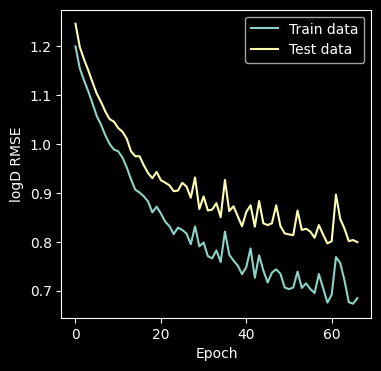


Model saved


In [15]:
# TRAINING AND TESTING

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)

def train(model, data_loader, loss_fn, optimizer):
  model.train()
  for i, (batch_data, target) in enumerate(data_loader):
    optimizer.zero_grad()
    output = model(batch_data.x, batch_data.edge_index, batch_data.batch)
    loss = loss_fn(output, target.unsqueeze(1))
    loss.backward()
    optimizer.step()

    if i % 10 == 0:
      loss_val = loss.item()
      current_samples = min((i + 1) * data_loader.batch_size, len(data_loader.dataset))
      print(f"loss: {loss_val:>7f}  [{current_samples:>5d}/{len(data_loader.dataset):>5d}]")

  print()

def evaluate(model, data_loader, loss_fn, dataset_name=""):
  model.eval()
  total_loss = 0
  with torch.no_grad():
    for i, (batch_data, target) in enumerate(data_loader):
      output = model(batch_data.x, batch_data.edge_index, batch_data.batch)
      total_loss += loss_fn(output, target.unsqueeze(1)).item()

  avg_loss = total_loss / len(data_loader)
  print(f"Average loss ({dataset_name}): {avg_loss:>8f}")

  pred_logd_rmse = avg_loss**0.5 * dataset.std
  print(f"Predicted LogD RMSE ({dataset_name}): {pred_logd_rmse:>8f}\n")

  return avg_loss


def train_model(
    model,
    train_loader,
    test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    patience=patience,
    limit=limit,
    plot=True,
    save=True,
):

  train_losses = []
  test_losses = []
  best_test_loss = float("inf")
  best_epoch = 0
  epochs_without_improvement = 0

  print("Initial model performane")
  train_loss = evaluate(model, train_loader, loss_fn, dataset_name="train data")
  train_losses.append(train_loss)
  test_loss = evaluate(model, test_loader, loss_fn, dataset_name="test data")
  test_losses.append(test_loss)

  for epoch in range(limit):
    print(f"Epoch {epoch + 1}/{limit}")
    train(model, train_loader, loss_fn, optimizer)

    print("Evaluating")
    train_loss = evaluate(model, train_loader, loss_fn, dataset_name="train data")
    train_losses.append(train_loss)
    test_loss = evaluate(model, test_loader, loss_fn, dataset_name="test data")
    test_losses.append(test_loss)

    lr_scheduler.step(test_loss)

    if test_loss < best_test_loss:
      torch.save(model.state_dict(), "best_model_weights.pth")
      best_test_loss = test_loss
      best_epoch = epoch
      epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1

    if epochs_without_improvement >= 1:
      print(f"Epochs without improvement: {epochs_without_improvement}")

      if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}")

        print(f"Loading best model (Epoch {best_epoch + 1})\n")
        model.load_state_dict(torch.load("best_model_weights.pth"))

        break

      print()

  print("Training and testing completed")

  # total parameters
  total_params = sum(param.numel() for param in model.parameters())
  print(f"Total parameters: {total_params:,}")

  # RMSE
  best_logd_rmse = best_test_loss**0.5 * dataset.std
  print(f"Predicted logD RMSE (test data): {best_logd_rmse:>8f}")
  print()

  # plot
  if plot:
    train_rmse = [loss**0.5 * dataset.std for loss in train_losses]
    test_rmse = [loss**0.5 * dataset.std for loss in test_losses]

    plt.style.use('dark_background')
    plt.figure(figsize=(4, 4))
    plt.plot(train_rmse, label="Train data")
    plt.plot(test_rmse, label="Test data")
    plt.xlabel("Epoch")
    plt.ylabel("logD RMSE")
    plt.legend()

    plt.show()
    print()

  # save
  if save:
    torch.save(model, "model.pth")
    torch.save(model.state_dict(), weights_path)
    print("Model saved")


if TRAIN_MODEL:
  train_model(model, train_loader, test_loader)

### Example Prediction

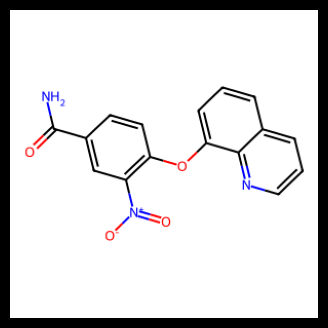

C16H11N3O4
Predicted logD: 1.98
True logD: 1.70
Error: 0.28


In [20]:
# EXAMPLE
visualization = "2d"

i = torch.randint(0, len(test_data), (1,)).item()
mol = Chem.MolFromSmiles(test_data.dataset.data.loc[i, "RDKIT_SMILES"])
formula = rdMolDescriptors.CalcMolFormula(mol)
exp = test_data.dataset.data.loc[i, "exp"]

model.eval()
pred = model.predict(mol)
error = abs(pred - exp)

if visualization not in ["2d", "3d", "none"]:
  raise ValueError("Visualization must be either '2d', '3d' or 'none'")

match visualization:

  case "2d":
    plt.figure(figsize=(4,4))
    plt.axis("off")
    image = Draw.MolToImage(mol)
    plt.imshow(image)
    plt.show()

  case "3d":
    view = py3Dmol.view(width=400, height=400)
    view.setBackgroundColor('black')
    view.addModel(mol_3d_from_mol(mol), "mol")
    view.setStyle({
        "stick": {},
        "sphere": {"scale": 0.3}
        })
    view.zoomTo()
    view.show()

print(formula)
print(f"Predicted logD: {pred:.2f}")
print(f"True logD: {exp:.2f}")
print(f"Error: {error:.2f}")